In [102]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Perceptron
from sklearn.datasets import make_blobs

In [103]:
X, y = make_blobs(n_samples=1000,n_features=2,centers=2)

In [104]:
X.shape

(1000, 2)

In [105]:
y.shape

(1000,)

<Axes: >

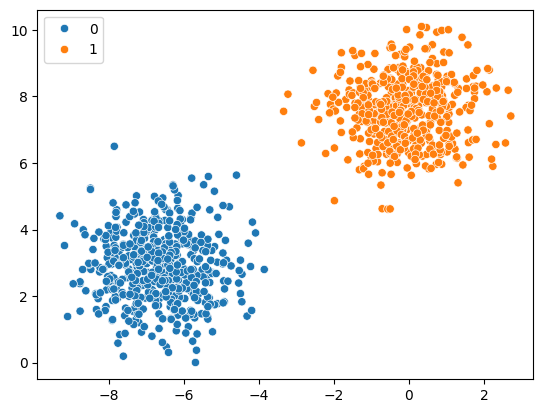

In [106]:
sns.scatterplot(x=X[:,0],y=X[:,1],hue=y)

In [107]:
clf = Perceptron(max_iter=1000,random_state=42)
clf.fit(X,y)

Perceptron(random_state=42)

In [108]:
w1 , w2 = clf.coef_[0]

In [109]:
b = clf.intercept_

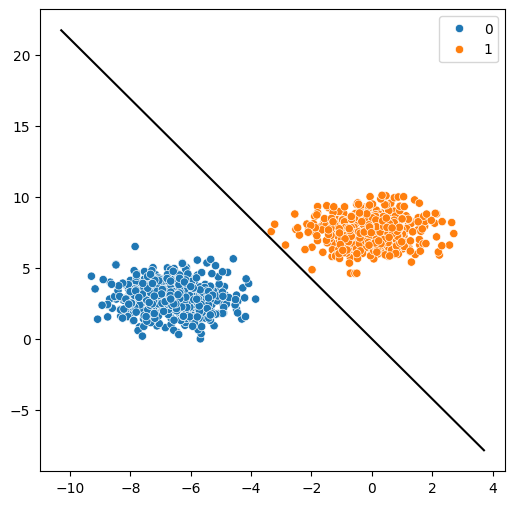

In [110]:
plt.figure(figsize=(6,6))
sns.scatterplot(x=X[:,0],y=X[:,1],hue=y)
x1s = np.array([X[:,0].min()-1,X[:,0].max()+1])
x2s = (-w1/w2)*x1s - b/w2
plt.plot(x1s,x2s,color='black')
plt.show()


<Axes: >

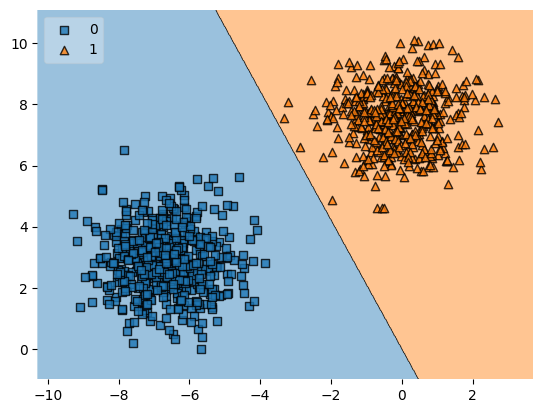

In [111]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y, clf=clf, legend=2)

#Theory


In [112]:
from sklearn.datasets import make_classification
X1, y1 = make_classification(n_samples=500,n_features=2,n_informative=1,n_redundant=0,n_classes=2,n_clusters_per_class=1,
                             random_state=42,hypercube=False,class_sep=4)

In [113]:
X1.shape

(500, 2)

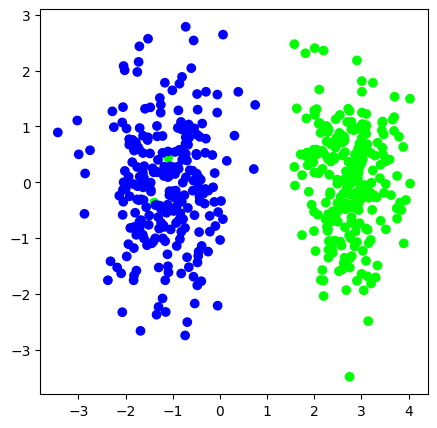

In [114]:
plt.figure(figsize=(5,5))
plt.scatter(X1[:,0],X1[:,1],c=y1,cmap='brg')

In [115]:
def step(a):
  return 1 if a>0 else 0

In [116]:
def perceptron(X,y,n_iter=1000):
  X = np.insert(X,0,1,axis=1) # adding bias.
  weights = np.ones(X.shape[1])
  lr = 0.1  # learning rate.

  for i in range(n_iter):
    j = np.random.randint(0,X.shape[0]-1) # selecting random datapoint.
    y_hat = step(np.dot(X[j],weights))

    weights = weights + lr*(y[j]-y_hat)*X[j] # weight updation.

  return weights[0], weights[1:]



In [117]:
b,w = perceptron(X1,y1,5000)
x11s = np.array([X1[:,0].min()-0.5,X1[:,0].max()+0.5])
y11s = -(w[0]/w[1])*x11s -b/w[1]

In [124]:
clf1 = Perceptron(max_iter=5000,random_state=42)
clf1.fit(X1,y1)

Perceptron(max_iter=5000, random_state=42)

In [125]:
from mlxtend.plotting import plot_decision_regions

Text(0.5, 1.0, 'Inbuilt Perceptron')

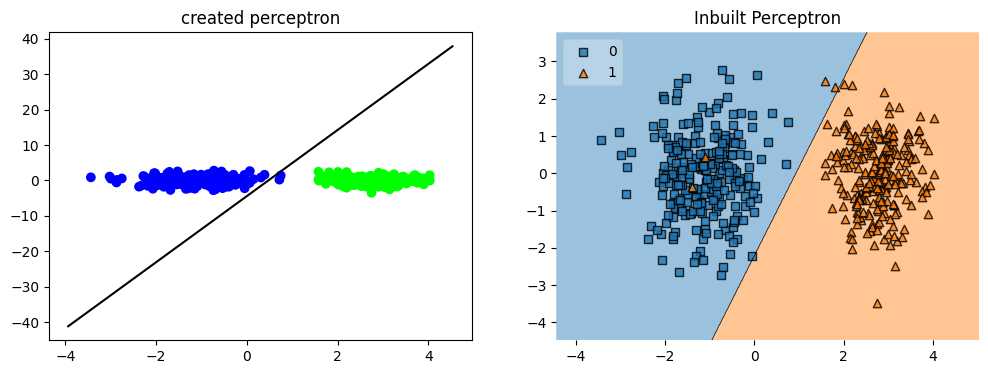

In [131]:
fig, axs = plt.subplots(1,2,figsize=(12,4))
axs[0].scatter(X1[:,0],X1[:,1],c=y1,cmap='brg')
axs[0].plot(x11s,y11s,c='black')
axs[0].set_title('created perceptron')
plot_decision_regions(X1,y1,clf=clf1,legend=2)
axs[1].set_title('Inbuilt Perceptron')

#Animation for 2D data

In [133]:
def perceptron_anime(X,y,n_iter=1000):

  m = []
  b = []

  X = np.insert(X,0,1,axis=1) # adding bias.
  weights = np.ones(X.shape[1])
  lr = 0.1  # learning rate.

  for i in range(n_iter):
    j = np.random.randint(0,X.shape[0]-1) # selecting random datapoint.
    y_hat = step(np.dot(X[j],weights))

    weights = weights + lr*(y[j]-y_hat)*X[j] # weight updation.

    m.append(-(weights[1]/weights[2]))
    b.append(-(weights[0]/weights[2]))

  return b,m



In [142]:
b, m = perceptron_anime(X1,y1,2500)

In [143]:
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation

In [145]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML
from matplotlib import rc
from matplotlib.animation import FuncAnimation

rc("animation", html="jshtml")

# 1. Setup boundaries based on your X1 dataset
x_min, x_max = X1[:, 0].min() - 0.5, X1[:, 0].max() + 0.5
y_min, y_max = X1[:, 1].min() - 0.5, X1[:, 1].max() + 0.5

fig, ax = plt.subplots(figsize=(9, 5))
x_i = np.arange(x_min, x_max, 0.1)

# Base scatter and line initialization
ax.scatter(X1[:, 0], X1[:, 1], c=y1, cmap="winter", s=100)
(line,) = ax.plot(x_i, x_i * m[0] + b[0], "r-", linewidth=2)

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)


def update(i):
    label = "epoch {0}".format(i + 1)
    line.set_ydata(x_i * m[i] + b[i])
    ax.set_xlabel(label)
    return (line,)


# 2. UPDATED FOR 500 LENGTH: frames set dynamically, interval sped up
anim = FuncAnimation(
    fig,
    update,
    repeat=True,
    frames=len(m),  # Dynamically reads the 500 length
    interval=40,  # 40ms interval = 25 frames per second
    blit=True,  # Crucial for 500 frames; speeds up rendering time significantly
)

plt.close()
HTML(anim.to_html5_video(embed_limit=50.0))
